# Price Forecasting — Model Training
Change settings in the **Settings** cell, then run cells top-to-bottom.
Training scripts live in `src/models/` — this notebook just calls them and shows results.

In [1]:
# ── Settings ─────────────────────────────────────────────────────────────────
import sys, pandas as pd
from datetime import date, timedelta
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

# END_DATE: latest date retrievable from the TIGGE archive (48-hour embargo).
# Workers in cell-3 will download any missing dates up to this target.
# After merging, training features use all dates present in weather_ensemble.parquet.
END_DATE = (date.today() - timedelta(days=2)).isoformat()

# Validation splits — kept fixed so KPIs remain comparable across retraining runs.
# Advance these manually when you want to shift the evaluation window forward.
VAL_START_DEFAULT     = "2026-05-01"   # TRL Daily + TRE
VAL_START_TRL_WEEKLY  = "2026-04-06"   # TRL Weekly (needs more weeks at weekly resolution)

# Quantiles to train
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

# TRE two-stage thresholds (CHF/MWh)
TRE_THRESHOLD_POS =  300.0   # above → extreme positive
TRE_THRESHOLD_NEG = -200.0   # below → extreme negative

print(f"  END_DATE (target): {END_DATE}  (today − 2 days, TIGGE embargo)")
print(f"  val_start default: {VAL_START_DEFAULT}")
print(f"  val_start weekly : {VAL_START_TRL_WEEKLY}")

  END_DATE (target): 2026-05-20  (today − 2 days, TIGGE embargo)
  val_start default: 2026-05-01
  val_start weekly : 2026-04-06


In [2]:
# ── Apply settings to config.yaml ────────────────────────────────────────────
import sys, subprocess, re, yaml
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

cfg_path = ROOT / "config" / "config.yaml"
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

cfg["training"]["end_date"]  = END_DATE
cfg["training"]["val_start"] = VAL_START_DEFAULT
cfg["training"]["quantiles"] = QUANTILES
cfg["models"]["trl_weekly"]["val_start"] = VAL_START_TRL_WEEKLY
cfg["models"]["tre"]["extreme_threshold_pos"] = TRE_THRESHOLD_POS
cfg["models"]["tre"]["extreme_threshold_neg"] = TRE_THRESHOLD_NEG

with open(cfg_path, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print("Config updated:")
print(f"  end_date         : {END_DATE}")
print(f"  val_start        : {VAL_START_DEFAULT}  (TRL Weekly: {VAL_START_TRL_WEEKLY})")
print(f"  quantiles        : {QUANTILES}")
print(f"  TRE threshold pos: > {TRE_THRESHOLD_POS} CHF/MWh")
print(f"  TRE threshold neg: < {TRE_THRESHOLD_NEG} CHF/MWh")

Config updated:
  end_date         : 2026-05-20
  val_start        : 2026-05-01  (TRL Weekly: 2026-04-06)
  quantiles        : [0.1, 0.25, 0.5, 0.75, 0.9]
  TRE threshold pos: > 300.0 CHF/MWh
  TRE threshold neg: < -200.0 CHF/MWh


In [3]:
# ── ECMWF weather (background, ~2 min per new date) ──────────────────────────
# Launches background workers for any dates not yet downloaded.
# Check progress with the --status cell below; merge when done.
# Update END_DATE in Settings first if needed.
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--status"],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)

subprocess.Popen(
     [sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--workers", "2"],
     cwd=str(ROOT)
     )
print("Workers launched — re-run this cell to check status, then merge when done.")


subprocess.run([sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--merge"],
               cwd=str(ROOT), capture_output=False)

Overall: 1601 / 1601 dates done (100.0%)

  main parquet : 1601 dates

  ecds_chunk_00.log: 2026-05-22 09:27:10  INFO      Done.
  ecds_chunk_01.log: 2026-05-22 09:25:37  INFO      Done.
  ecds_chunk_02.log: 2026-05-09 18:03:57  INFO      Done.
  ecds_chunk_03.log: 2026-05-09 15:32:20  INFO      Done.
  ecds_chunk_04.log: 2026-05-09 05:19:52  INFO      Done.
  ecds_chunk_05.log: 2026-05-06 10:04:51  INFO      Done.

Workers launched — re-run this cell to check status, then merge when done.


CompletedProcess(args=['c:\\Users\\ThijsAntoniedeBoer\\OneDrive - HELION\\Dokumente\\python-projects\\standard_env\\Scripts\\python.exe', 'C:\\Users\\ThijsAntoniedeBoer\\OneDrive - HELION\\Dokumente\\Price Forecasting\\src\\data\\ecds_parallel_launch.py', '--merge'], returncode=0)

In [4]:
# ── TRE prices (Swissgrid) ────────────────────────────────────────────────────
import subprocess, sys
from pathlib import Path
ROOT = Path().resolve().parent
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/update_tre_prices.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Found 5 TRE file(s) on Swissgrid:
  2026-01-TRE-Ergebnis.csv
  2026-02-TRE-Ergebnis.csv
  2026-03-TRE-Ergebnis.csv
  2026-04-TRE-Ergebnis.csv.zip
  2026-05-TRE-Ergebnis.csv.zip
  Skipping 2026-01-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-02-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-03-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-04-TRE-Ergebnis.csv.zip (already in parquet)

Saved 233048 rows to tre_slots.parquet
Latest slot: 2026-05-21 21:45:00+00:00



In [5]:
# ── Spot prices + TRL Weekly/Daily + reservoir levels (from Helion dashboard) ─────────────────────────────────────────────────────────
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/market_data.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
clean = "\n".join(
    re.sub(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+', '', l)
    for l in (result.stdout + result.stderr).splitlines()
)
print(clean if clean.strip() else "(no output)")
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Fetching market data from GitHub ...
processedAt: 2026-05-22T04:56:13.890910+00:00
Parsing TRL Weekly ...
Saved 494 rows â†’ trl_weekly.parquet
Parsing TRL Daily ...
Saved 18882 rows â†’ trl_daily.parquet
Parsing TRE Slots ...
Saved 232856 rows â†’ tre_slots.parquet
Parsing Spot Hourly ...
Saved 38472 rows â†’ spot_hourly.parquet
Parsing Reservoir Levels ...
Fetching reservoir levels from opendata.swiss ...
Saved 1377 rows â†’ reservoir_levels.parquet
Done.


---
## Data update
Run before retraining to pull the latest prices and weather.
Run cells in order — Rebuild features must come after all source data is updated.

| Step | Cell | Source | Speed |
|---|---|---|---|
| ECMWF weather | 3 | ECDS archive | ~2 min/date, background |
| TRE prices | 4 | Swissgrid tenders page | ~30s |
| Spot + TRL + reservoir | 5 | Helion dashboard (GitHub) | ~5s |
| Rebuild features | 6 | local computation | ~15s |

In [17]:
# ── Rebuild features ─────────────────────────────────────────────────────────
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/feature_store.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
clean = "\n".join(
    re.sub(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+', '', l)
    for l in (result.stdout + result.stderr).splitlines()
)
print(clean if clean.strip() else "Done.")
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Building TRL Weekly features ...
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:427: RuntimeWarning: All-NaN slice encountered
  daily_spreads[:, d] = np.nanmax(day_p, axis=1) - np.nanmin(day_p, axis=1)
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:430: RuntimeWarning: Mean of empty slice
  "spot_baseload_mean":     np.nanmean(prices, axis=1),
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:431: RuntimeWarning: Mean of empty slice
  "spot_peakload_mean":     np.nanmean(np.where(is_peak, prices, np.nan), axis=1),
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:432: RuntimeWarning: All-NaN slice encountered
  "spot_max":               np.nanmax(prices, axis=1),
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:433: RuntimeWarning: 

---
## Train models
Run individually or all at once. Output shows pinball loss per quantile.

In [26]:
import subprocess, re

_LOG_PREFIX = re.compile(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+')

def run_script(script: str) -> tuple[str, list[dict]]:
    """Run a training script, stream output, return (stdout, parsed pinball rows)."""
    result = subprocess.run(
        [sys.executable, str(ROOT / script)],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    out = result.stdout + result.stderr
    clean = "\n".join(_LOG_PREFIX.sub("", l) for l in out.splitlines())
    print(clean)
    # Parse pinball lines — two formats:
    #   new (TRL Weekly): "q=0.10  n_est=142  pinball_es=...  pinball_kpi=17.19"
    #   old (TRL Daily / TRE): "q=0.10  pinball=4.03  best_iter=69"
    rows = []
    for line in out.splitlines():
        m = re.search(r'\[(\w+)/(\w+)\]', line)
        if m:
            cur_dir = m.group(2)
        m2 = re.search(r'q=(\d\.\d+).*pinball_kpi=([\d\.]+)', line)
        if not m2:
            m2 = re.search(r'q=(\d\.\d+)\s+pinball=([\d\.]+)', line)
        if m2:
            rows.append({"direction": cur_dir,
                         "q": float(m2.group(1)),
                         "pinball": float(m2.group(2))})
    return out, rows

In [27]:
print("=" * 60)
print("TRL Weekly")
print("=" * 60)
_, rows_weekly = run_script("src/models/trl_weekly_model.py")

TRL Weekly
[trl_weekly/up] train=118  es_val=68  kpi_val=8
q=0.10  CV best_iters=[32, 1, 23]  â†’ n_estimators=30
q=0.10  n_est=30  pinball_es=18.6480 (norm=0.0696)  pinball_kpi=25.6256 (norm=0.0467)
q=0.25  CV best_iters=[1, 24, 265]  â†’ n_estimators=116
q=0.25  n_est=116  pinball_es=24.9367 (norm=0.0931)  pinball_kpi=27.4410 (norm=0.0500)
q=0.50  CV best_iters=[11, 50, 257]  â†’ n_estimators=127
q=0.50  n_est=127  pinball_es=41.7193 (norm=0.1558)  pinball_kpi=33.4246 (norm=0.0609)
q=0.75  CV best_iters=[1, 63, 272]  â†’ n_estimators=134
q=0.75  n_est=134  pinball_es=45.6339 (norm=0.1704)  pinball_kpi=34.3954 (norm=0.0626)
q=0.90  CV best_iters=[4, 97, 173]  â†’ n_estimators=109
q=0.90  n_est=109  pinball_es=44.1703 (norm=0.1649)  pinball_kpi=37.2222 (norm=0.0678)
Saved â†’ trl_weekly_up.pkl
[trl_weekly/down] train=118  es_val=68  kpi_val=8
q=0.10  CV best_iters=[1, 25, 6]  â†’ n_estimators=30
q=0.10  n_est=30  pinball_es=168.8269 (norm=0.1605)  pinball_kpi=78.0198 (norm=0.0697)
q=0.

In [28]:
print("=" * 60)
print("TRL Daily")
print("=" * 60)
_, rows_daily = run_script("src/models/trl_daily_model.py")

TRL Daily
[trl_daily/up] train=5196  val=143
q=0.10  pinball=0.8206 (norm=0.0724)  best_iter=68
q=0.25  pinball=1.8926 (norm=0.1670)  best_iter=113
q=0.50  pinball=3.1616 (norm=0.2789)  best_iter=117
q=0.75  pinball=4.1218 (norm=0.3636)  best_iter=171
q=0.90  pinball=3.9303 (norm=0.3467)  best_iter=125
Saved â†’ trl_daily_up.pkl
[trl_daily/down] train=4859  val=136
q=0.10  pinball=5.9249 (norm=0.0697)  best_iter=161
q=0.25  pinball=10.8153 (norm=0.1273)  best_iter=147
q=0.50  pinball=14.4930 (norm=0.1706)  best_iter=321
q=0.75  pinball=15.1570 (norm=0.1784)  best_iter=349
q=0.90  pinball=12.7001 (norm=0.1495)  best_iter=118
Saved â†’ trl_daily_down.pkl

direction  quantile  pinball_kpi  pinball_kpi_norm
       up      0.10     0.820565          0.072392
       up      0.25     1.892582          0.166968
       up      0.50     3.161584          0.278923
       up      0.75     4.121766          0.363633
       up      0.90     3.930315          0.346743
     down      0.10     5.924850

In [29]:
print("=" * 60)
print("TRE (two-stage)")
print("=" * 60)
_, rows_tre = run_script("src/models/tre_model.py")

TRE (two-stage)
[tre/pos] train=9564 (extreme=79, 0.8%)  val=1912 (extreme=19, 1.0%)
Classifier  AUC=0.7117  best_iter=4
Normal  train=9485 val=1893  |  Extreme  train=79 val=19
q=0.10  pinball=10.4525 (norm=0.1241)
q=0.25  pinball=24.5257 (norm=0.2912)
q=0.50  pinball=39.7080 (norm=0.4715)
q=0.75  pinball=40.7279 (norm=0.4836)
q=0.90  pinball=30.2376 (norm=0.3590)
Saved -> tre_pos.pkl
[tre/neg] train=9564 (extreme=122, 1.3%)  val=1912 (extreme=51, 2.7%)
Classifier  AUC=0.7638  best_iter=1
Normal  train=9442 val=1861  |  Extreme  train=122 val=51
q=0.10  pinball=35.9040 (norm=3.0494)
q=0.25  pinball=52.0610 (norm=4.4217)
q=0.50  pinball=50.1960 (norm=4.2633)
q=0.75  pinball=39.8755 (norm=3.3867)
q=0.90  pinball=21.8503 (norm=1.8558)
Saved -> tre_neg.pkl

direction  quantile  pinball_kpi  pinball_kpi_norm  clf_auc
      pos      0.10    10.452549          0.124108 0.711680
      pos      0.25    24.525678          0.291204 0.711680
      pos      0.50    39.707963          0.471471 0.71

---
## Results — Pinball loss on validation set

In [30]:
import pandas as pd

def pinball_table(rows, model_name):
    if not rows:
        print(f"{model_name}: no results parsed")
        return
    df = pd.DataFrame(rows)
    pt = df.pivot(index="direction", columns="q", values="pinball").round(2)
    pt.columns = [f"q{c:.2f}" for c in pt.columns]
    print(f"\n{'─'*50}")
    print(f"  {model_name}  — pinball loss (val set, CHF/MWh or CHF/MW)")
    print(f"{'─'*50}")
    display(pt)

pinball_table(rows_weekly, "TRL Weekly")
pinball_table(rows_daily,  "TRL Daily")
pinball_table(rows_tre,    "TRE (two-stage)")


──────────────────────────────────────────────────
  TRL Weekly  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
down,78.02,114.35,250.76,505.18,297.54
up,25.63,27.44,33.42,34.40,37.22



──────────────────────────────────────────────────
  TRL Daily  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
down,5.92,10.82,14.49,15.16,12.70
up,0.82,1.89,3.16,4.12,3.93



──────────────────────────────────────────────────
  TRE (two-stage)  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
neg,35.90,52.06,50.20,39.88,21.85
pos,10.45,24.53,39.71,40.73,30.24


---
## Revenue Backtest (pay-as-bid)
All three markets use pay-as-bid clearing — you earn your own bid price, not the clearing price.

**Optimal bid:** for each slot, pick the quantile `q` that maximises expected profit:
- Positive-price markets: `(price[q] − opp_cost) × (1 − q)` — higher q = more profit per MW but lower selection probability
- TRE neg: `(|price[q]| − 200) × q` — uses the extreme-regime model (prices conditional on clearing < −200 CHF/MWh)

**Columns:** `opt_select_%` = fraction of val-set slots where our bid was accepted · `capture_%` = our P&L ÷ oracle P&L (oracle knows the clearing price in advance)

In [31]:
# ── Revenue backtest (pay-as-bid) ─────────────────────────────────────────────
import sys, yaml, importlib, json
from pathlib import Path
import pandas as pd
from datetime import datetime

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import src.pipeline.bid_strategy    as bs
import src.models.trl_weekly_model  as _m_w
import src.models.trl_daily_model   as _m_d
import src.models.tre_model         as _m_t
for _mod in (bs, _m_w, _m_d, _m_t):
    importlib.reload(_mod)

FC_W = _m_w.FEATURE_COLS_BY_DIRECTION
FC_D = _m_d.FEATURE_COLS_BY_DIRECTION
FC_T = _m_t.FEATURE_COLS

with open(ROOT / "config" / "config.yaml") as f:
    cfg = yaml.safe_load(f)

quantiles   = cfg["training"]["quantiles"]
val_default = cfg["training"]["val_start"]
val_weekly  = cfg["models"]["trl_weekly"].get("val_start") or val_default
tre_neg_opp = abs(cfg["models"]["tre"]["extreme_threshold_neg"])  # 200 CHF/MWh

FP = ROOT / "data/processed/features"
MP = ROOT / "models"

CASES = [
    dict(label="TRL Weekly  up",   fp=FP/"trl_weekly_features.parquet", tc="week_start",  d="up",   fc=FC_W["up"],   mp=MP/"trl_weekly/trl_weekly_up.pkl",   vs=val_weekly,  mode="pos_market", oc=0.0),
    dict(label="TRL Weekly  down", fp=FP/"trl_weekly_features.parquet", tc="week_start",  d="down", fc=FC_W["down"], mp=MP/"trl_weekly/trl_weekly_down.pkl", vs=val_weekly,  mode="pos_market", oc=0.0),
    dict(label="TRL Daily   up",   fp=FP/"trl_daily_features.parquet",  tc="block_start", d="up",   fc=FC_D["up"],   mp=MP/"trl_daily/trl_daily_up.pkl",     vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRL Daily   down", fp=FP/"trl_daily_features.parquet",  tc="block_start", d="down", fc=FC_D["down"], mp=MP/"trl_daily/trl_daily_down.pkl",   vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRE         pos",  fp=FP/"tre_features.parquet",        tc="slot_time",   d="pos",  fc=FC_T, mp=MP/"tre/tre_pos.pkl",                vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRE         neg",  fp=FP/"tre_features.parquet",        tc="slot_time",   d="neg",  fc=FC_T, mp=MP/"tre/tre_neg.pkl",                vs=val_default, mode="neg_market", oc=tre_neg_opp),
]

rows = []
for c in CASES:
    res = bs.run_backtest(
        features_parquet=c["fp"], time_col=c["tc"], direction=c["d"],
        feature_cols=c["fc"],     model_pkl=c["mp"], quantiles=quantiles,
        val_start=c["vs"],        opp_cost=c["oc"],  mode=c["mode"],
    )
    if res.empty:
        rows.append({"market": c["label"], "slots": 0})
        continue
    oracle_sum = res["oracle_pnl_chf"].sum()
    rows.append({
        "market":          c["label"],
        "slots":           len(res),
        "opt_select_%":    round(res["selected"].mean()        * 100, 1),
        "med_select_%":    round(res["median_selected"].mean() * 100, 1),
        "opt_pnl/slot":    round(res["pnl_chf"].mean(),         2),
        "med_pnl/slot":    round(res["median_pnl_chf"].mean(),  2),
        "oracle_pnl/slot": round(res["oracle_pnl_chf"].mean(),  2),
        "capture_%":       round(res["pnl_chf"].sum() / oracle_sum * 100, 1) if oracle_sum > 0 else float("nan"),
    })

print("Pay-as-bid revenue backtest — val set  (CHF per MW-slot, capacity = 1 MW)")
print("  opt_select_%  : fraction of slots our optimal bid was accepted")
print("  capture_%     : our P&L / oracle P&L  (oracle = perfect-foresight bid)\n")
display(pd.DataFrame(rows).set_index("market"))

# Save results — timestamped file preserves every run; latest file is the /log shortcut
_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
_payload = {"timestamp": _ts, "results": rows}
_runs_dir = ROOT / "data" / "processed" / "backtest_runs"
_runs_dir.mkdir(exist_ok=True)
(_runs_dir / f"backtest_{_ts}.json").write_text(json.dumps(_payload, indent=2))
(ROOT / "data" / "processed" / "backtest_latest.json").write_text(json.dumps(_payload, indent=2))
print(f"\nResults saved → backtest_runs/backtest_{_ts}.json  +  backtest_latest.json")

Pay-as-bid revenue backtest — val set  (CHF per MW-slot, capacity = 1 MW)
  opt_select_%  : fraction of slots our optimal bid was accepted
  capture_%     : our P&L / oracle P&L  (oracle = perfect-foresight bid)



,slots,opt_select_%,med_select_%,opt_pnl/slot,med_pnl/slot,oracle_pnl/slot,capture_%
market,,,,,,,
TRL Weekly up,8,87.5,62.5,413.15,327.92,549.22,75.2
TRL Weekly down,8,25.0,12.5,332.58,194.24,1120.16,29.7
TRL Daily up,131,40.5,22.1,3.51,3.16,12.24,28.7
TRL Daily down,126,54.8,30.2,39.13,32.36,77.22,50.7
TRE pos,1912,35.9,44.2,39.15,30.04,84.22,46.5
TRE neg,1912,0.3,0.9,7.40,5.60,26.98,27.4



Results saved → backtest_runs/backtest_20260522_154133.json  +  backtest_latest.json


---
## SHAP Feature Importance
Run `notebooks/04_shap_importance.py` first to regenerate plots after training.

In [32]:
print("Generating SHAP plots ...")
run_script("notebooks/04_shap_importance.py")
print("Done.")

Generating SHAP plots ...
TRL Weekly ...
Saved -> shap_trl_weekly.png
TRL Daily ...
Saved -> shap_trl_daily.png
TRE ...
Saved -> shap_tre_normal.png
Saved -> shap_tre_classifier.png
Done. Figures saved to notebooks/figures/
  shap_tre_normal.png    â€” normal-regime quantile model (q=0.50)
  shap_tre_classifier.png â€” classifier: what drives P(extreme price)
Done.



TRL Weekly


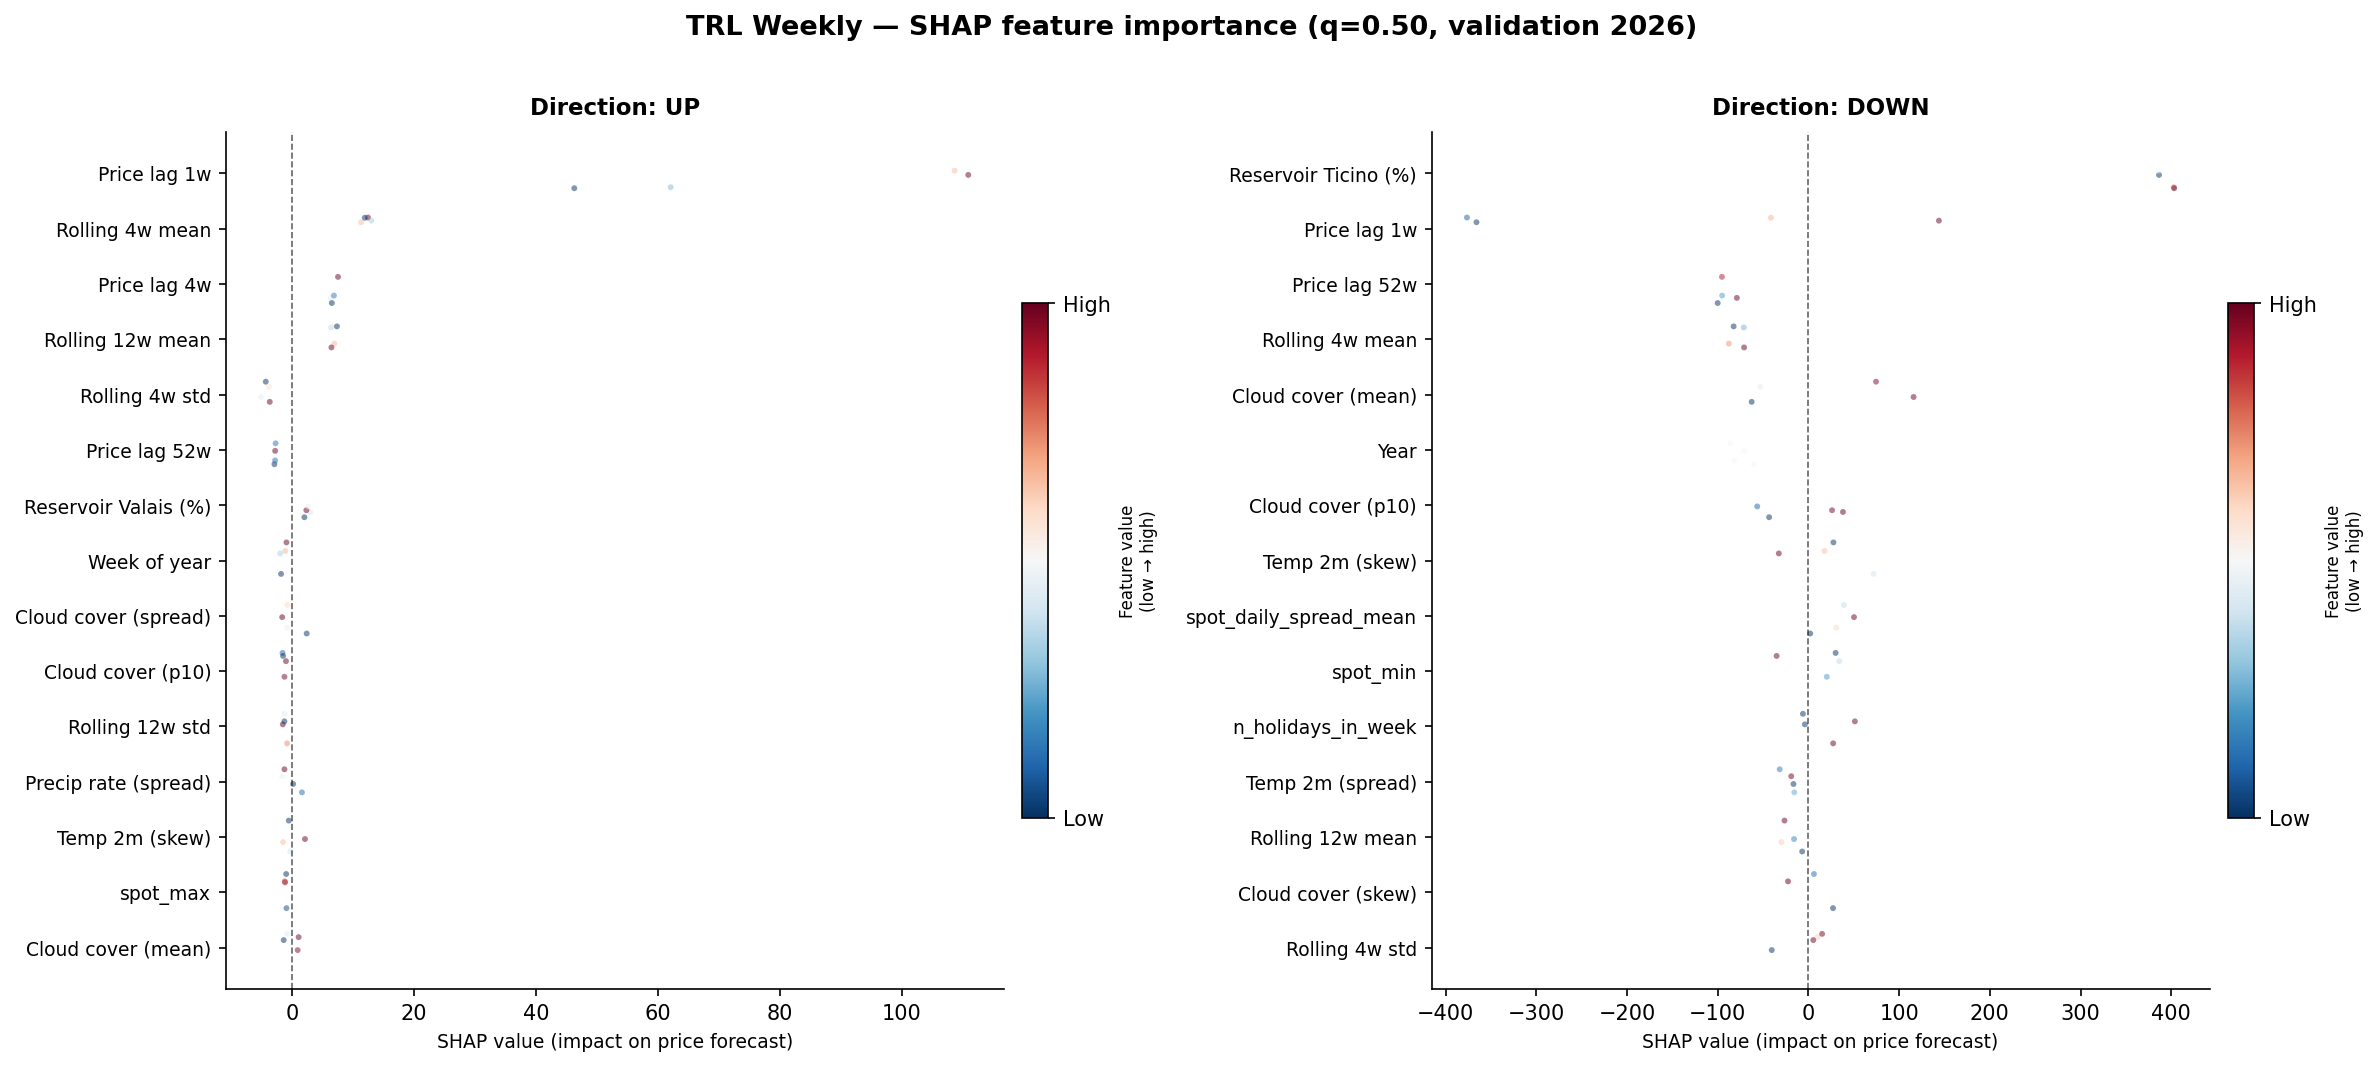


TRL Daily


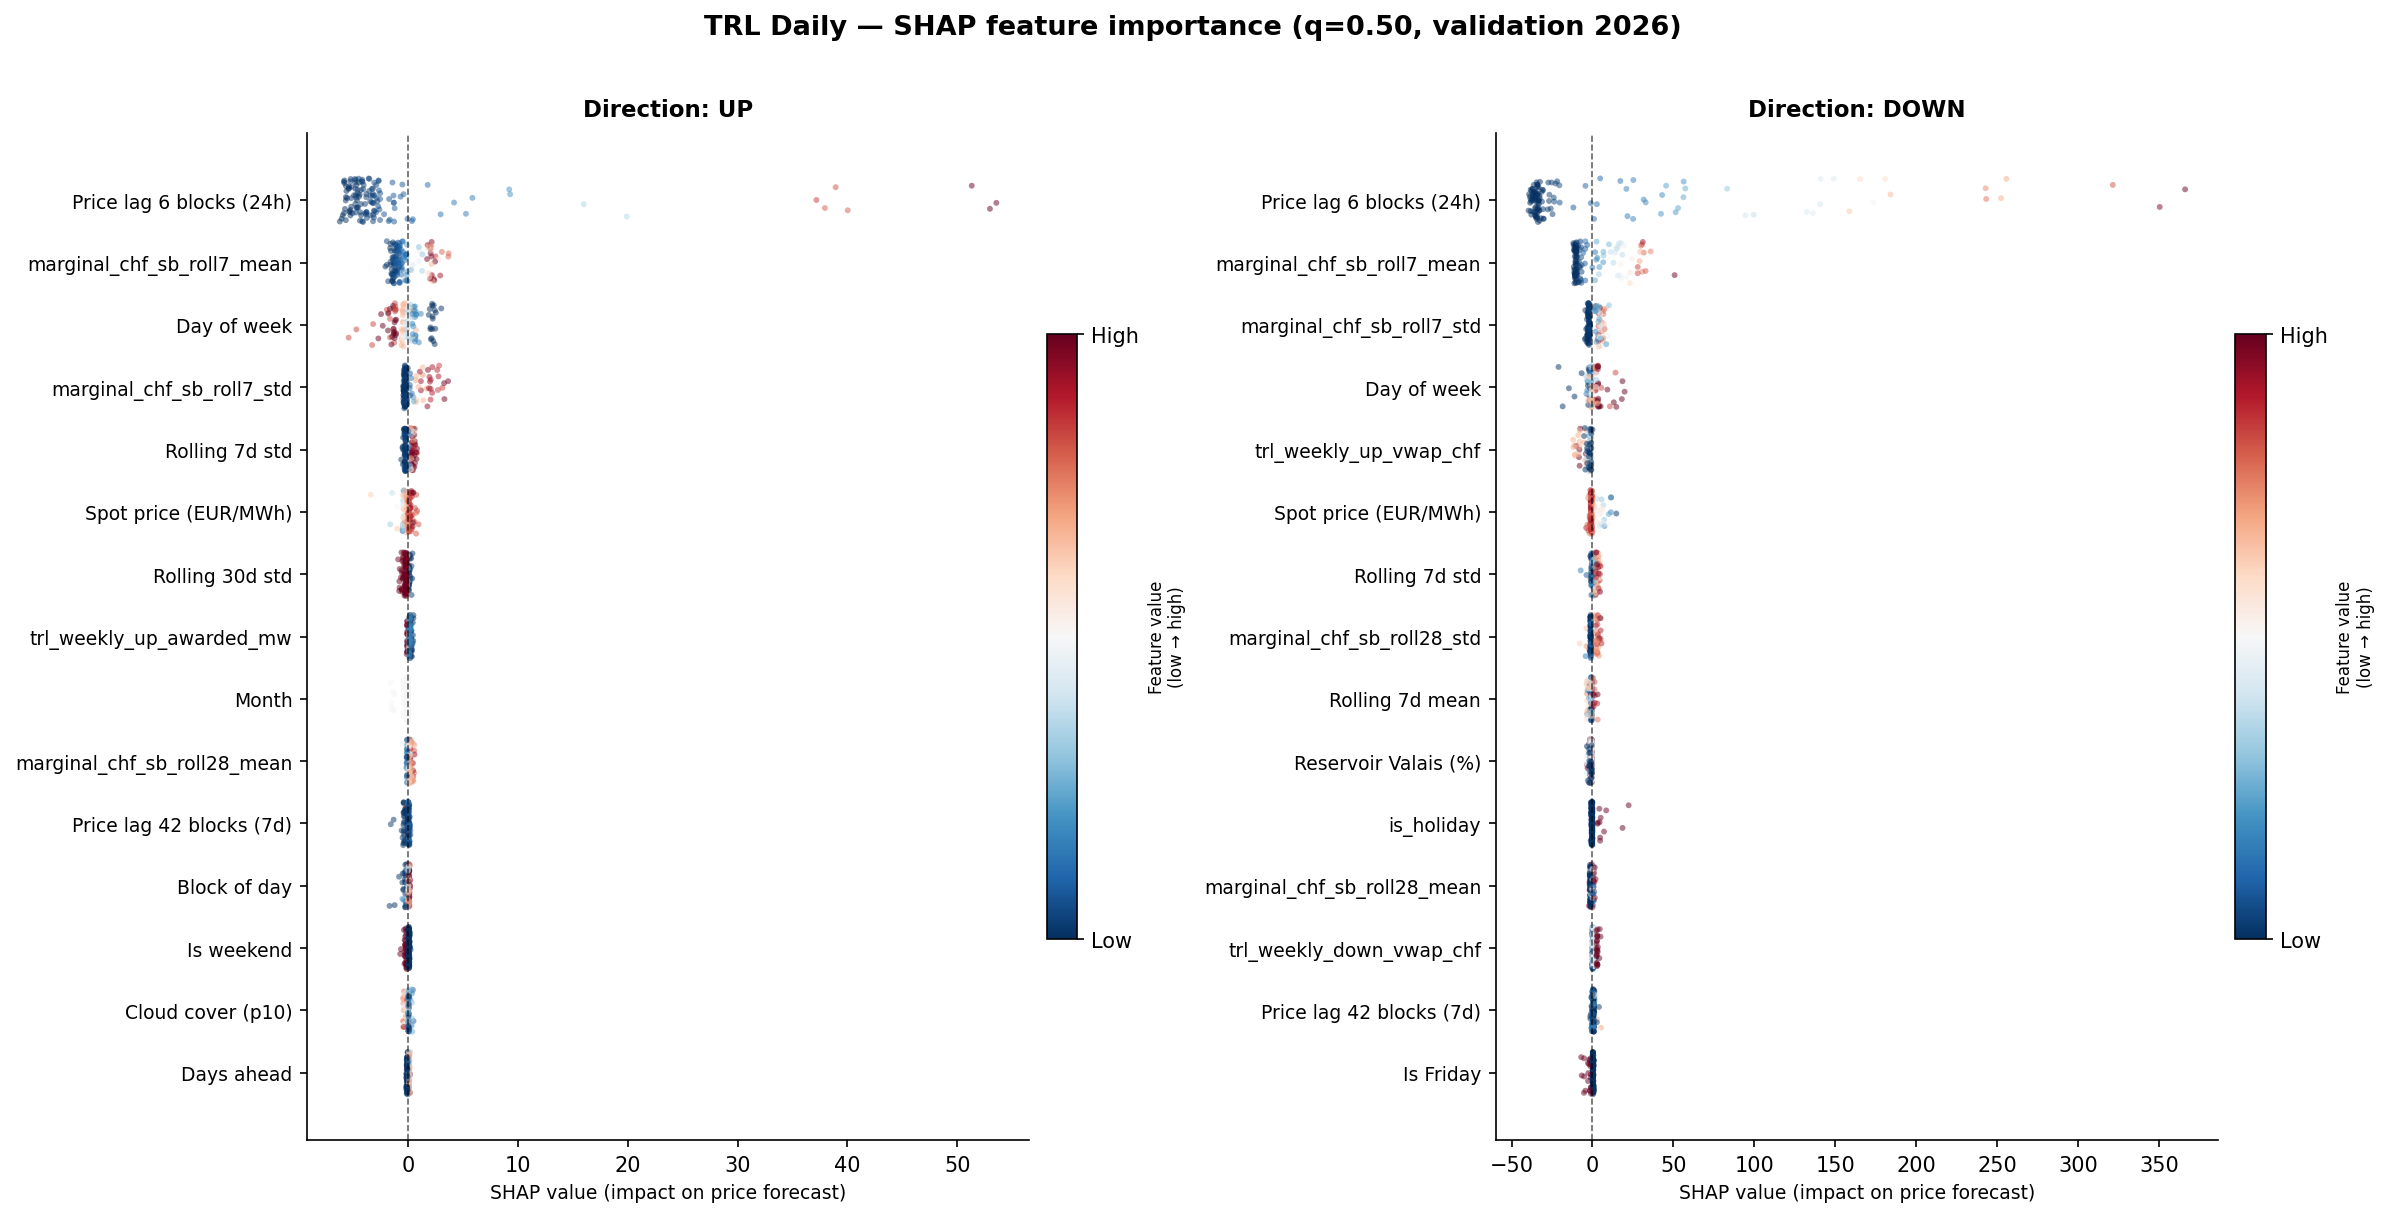


TRE — Normal regime (q=0.50)


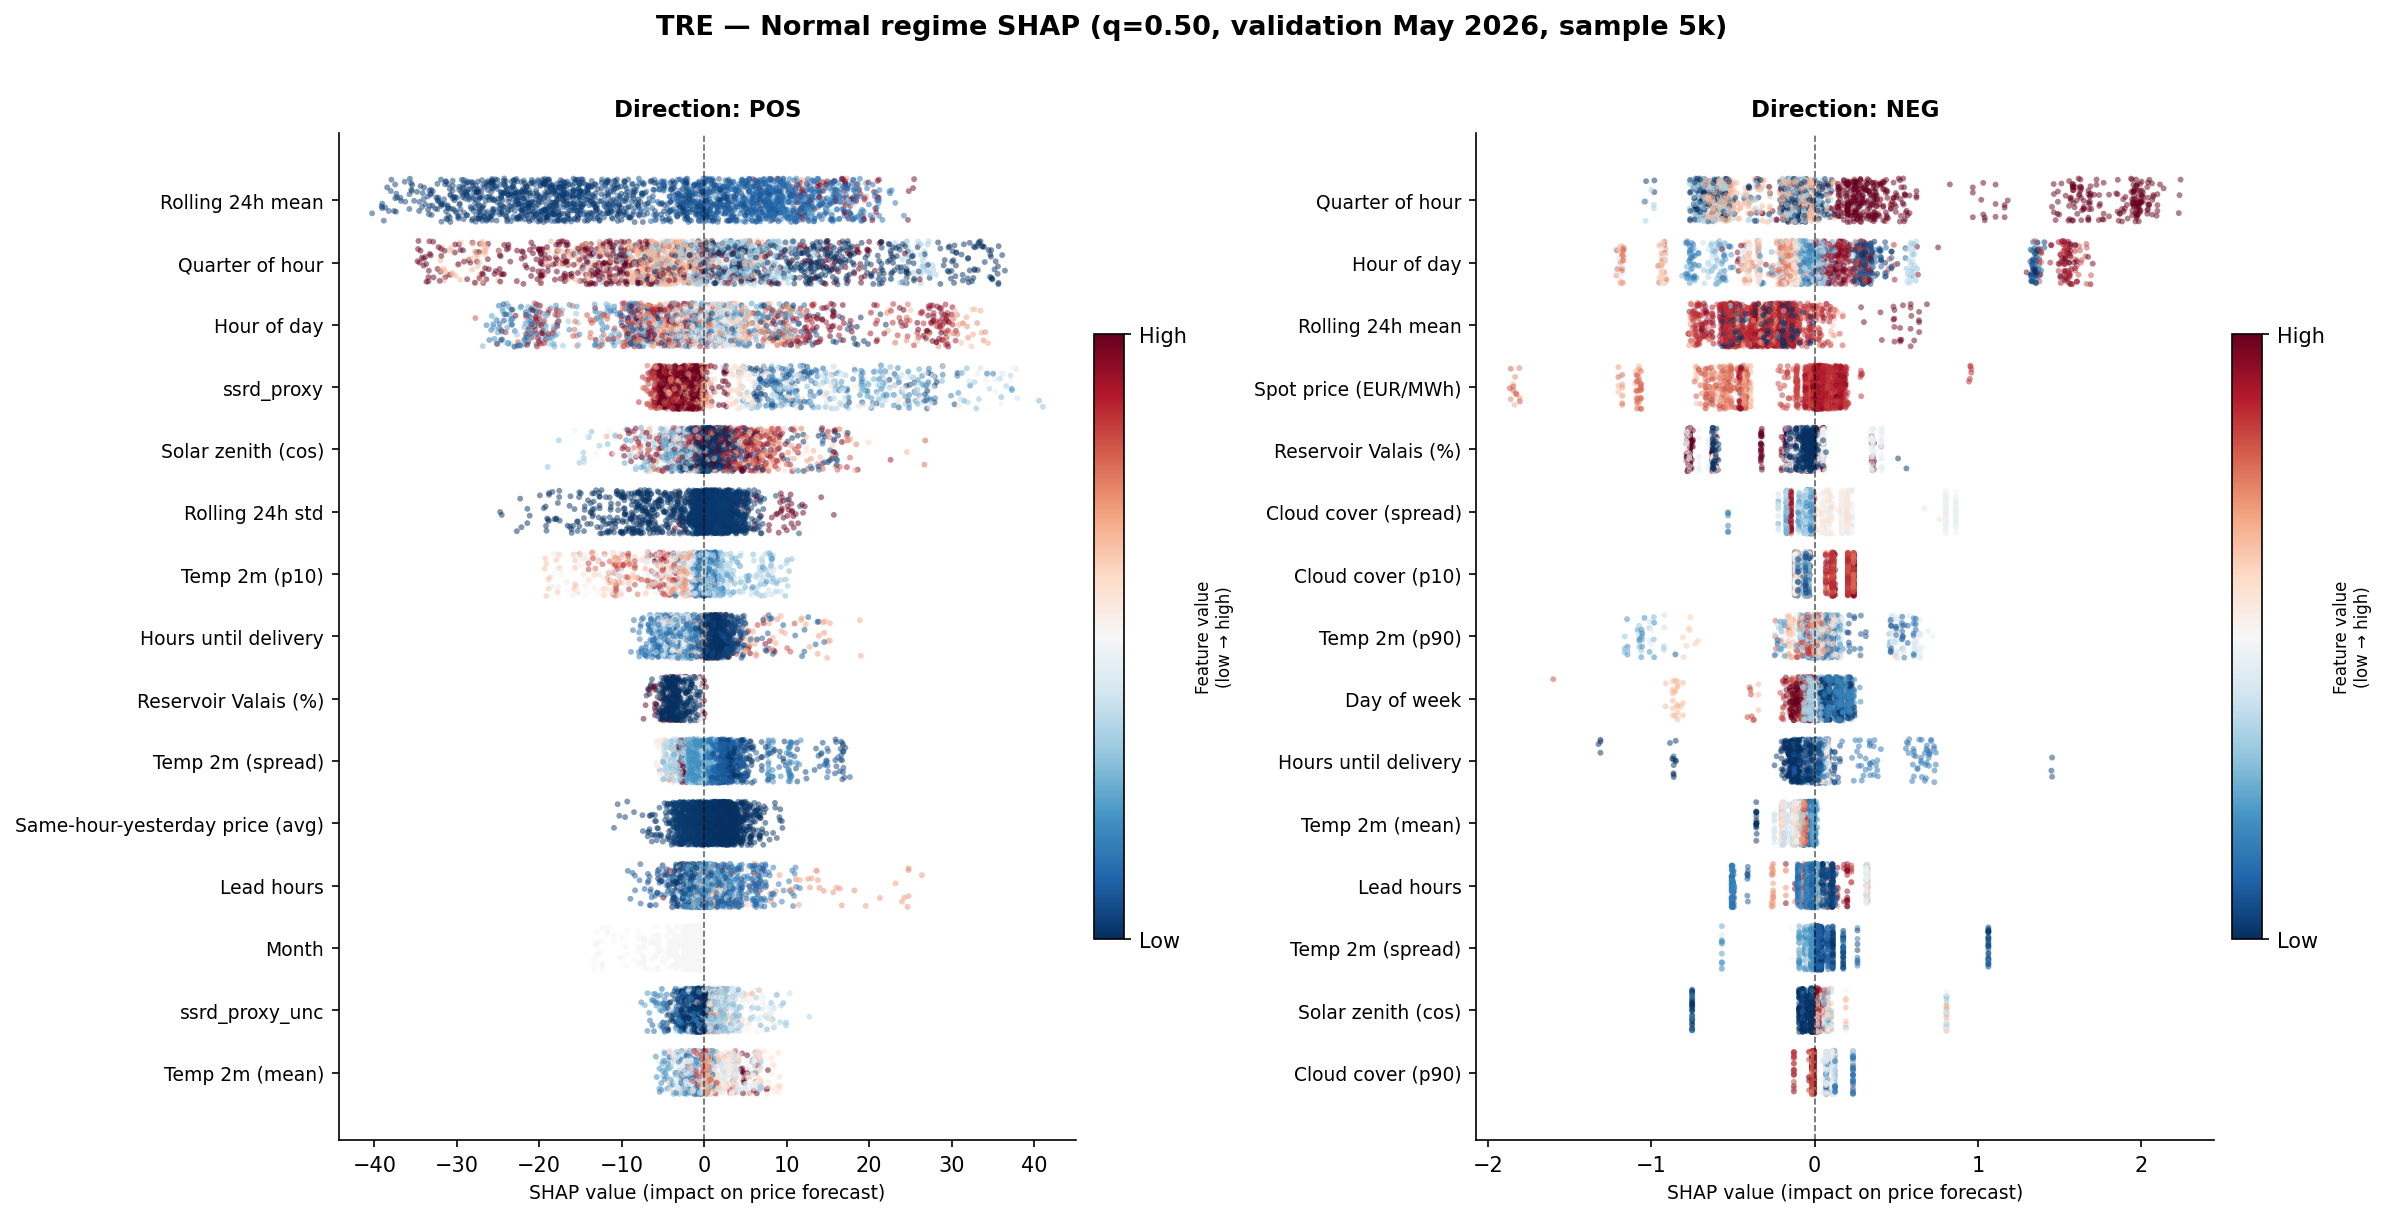


TRE — Classifier P(extreme)


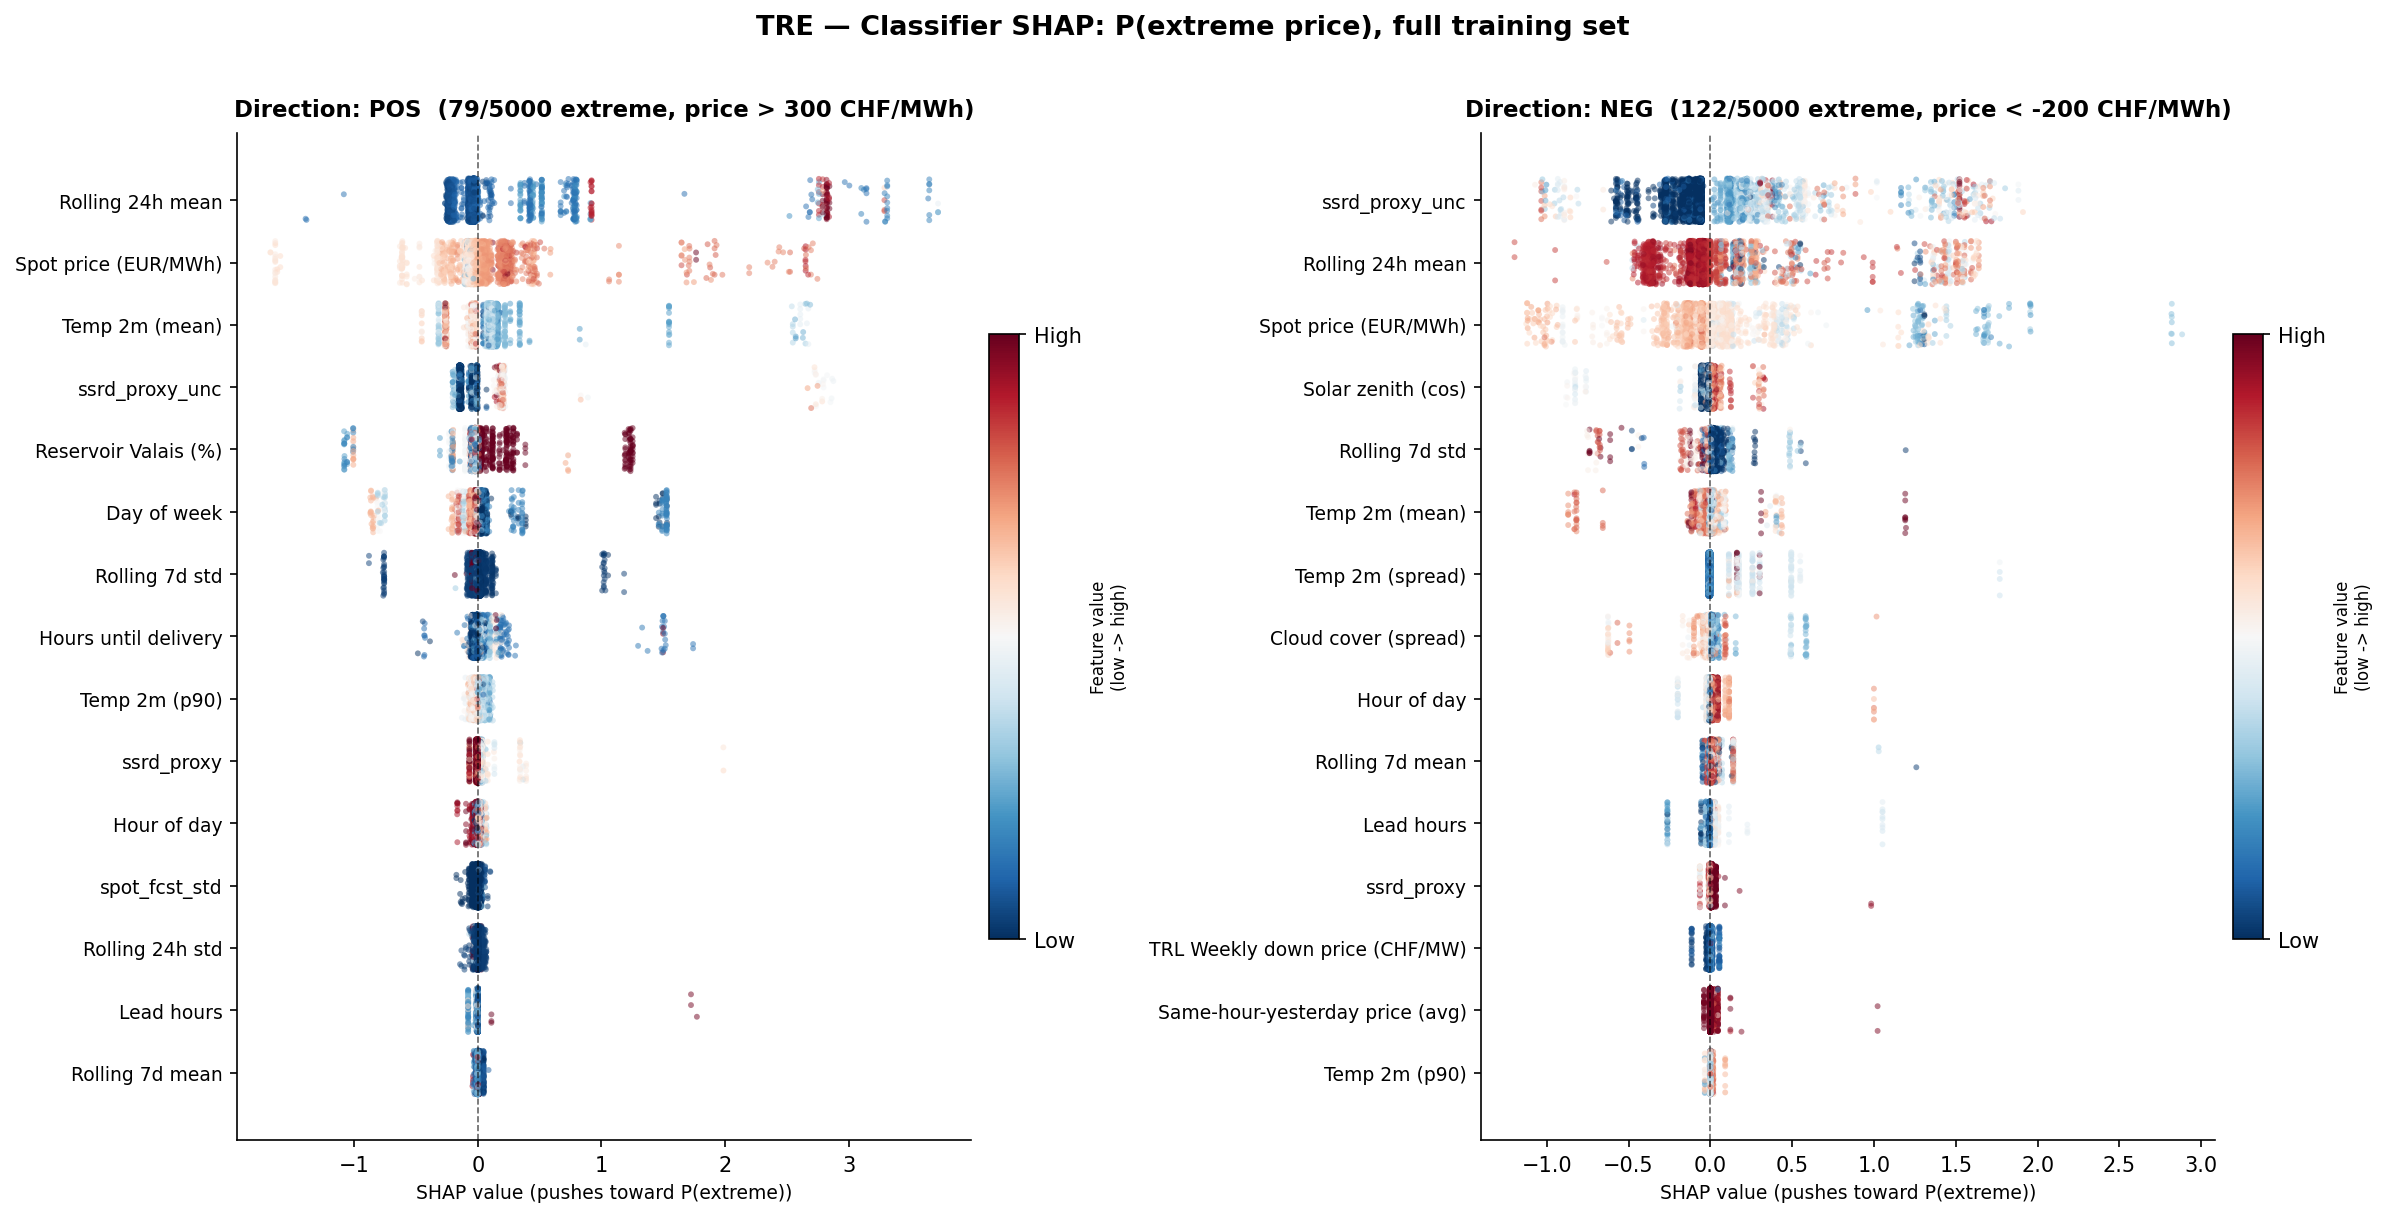

In [33]:
from IPython.display import Image, display as ipy_display

figures = ROOT / "notebooks" / "figures"

for title, fname in [
    ("TRL Weekly",                   "shap_trl_weekly.png"),
    ("TRL Daily",                    "shap_trl_daily.png"),
    ("TRE — Normal regime (q=0.50)", "shap_tre_normal.png"),
    ("TRE — Classifier P(extreme)",  "shap_tre_classifier.png"),
]:
    path = figures / fname
    if path.exists():
        print(f"\n{title}")
        ipy_display(Image(str(path)))
    else:
        print(f"Missing: {fname}")